# Weekly project part 1
Using the image "appletree.jpg"
1) Can you segment the apples from the tree?
2) Can you get the computer to count how many there are? 
    How close can you get to the ground truth? (there are 26 apples in the image)
3) Can you change the color of one of them?
4) Can you segment the leaves?
    
    
# Weekly project part 2
1) Remove the greenscreen and replace the background in "itssp.png".
2) Can you improve the edge with eroding/dilating?


In [89]:
import cv2
import numpy as np
import imutils
from matplotlib import pyplot as plt

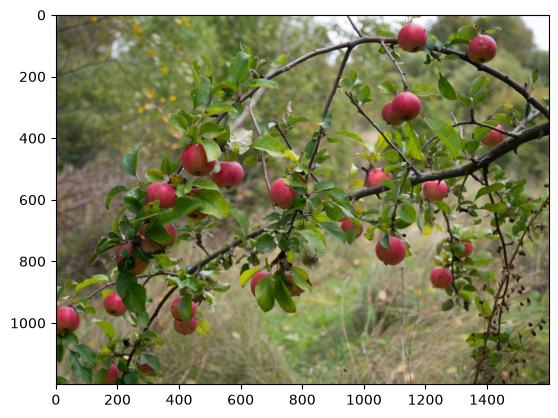

In [90]:
img = cv2.imread('appletree.jpg')
b,g,r = cv2.split(img)
image = cv2.merge([r,g,b])
plt.imshow(image)

For the filtering of the apples, we decided to use HSV colors, by applying specific upper and low limits to keep the reddish shades. We created 2 masks which we applied. Then, to delete the small holes created after the filtering process, we applied erosion with "cv2.erode" and then for the image to return to its initial size, we applied dilation with "cv2.dilate". 

In [91]:
#Task 1 and 2

hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
lower_red1 = np.array([0, 100, 50])
upper_red1 = np.array([12, 255, 255])
lower_red2 = np.array([150, 100, 50])
upper_red2 = np.array([180, 255, 255])

mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
mask = cv2.bitwise_or(mask1, mask2)

mask = cv2.erode(mask, None, iterations=4) 
mask = cv2.dilate(mask, None, iterations=7)


The next step is to draw contours by using "cv2.drawContours" in order to count the separate apples created.

Found 26 apples


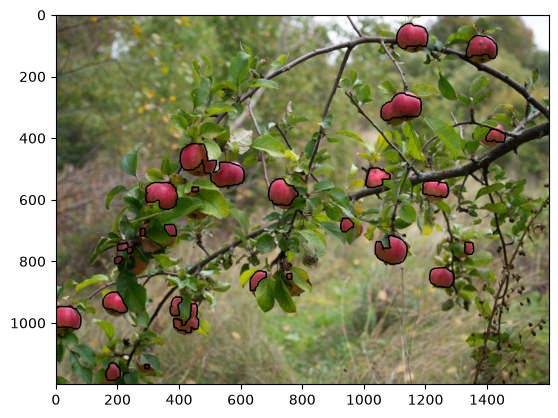

In [92]:
#Task 1 
cnts = cv2.findContours(mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)

output = image.copy()
for c in cnts:
    cv2.drawContours(output, [c], -1, (0, 0, 0), 3)
    
plt.imshow(output)

print(f"Found {len(cnts)} apples") #Task 2 result

# plt.figure(figsize=(128,32))
# plt.subplot(1,2,1)
# plt.imshow(image)
# plt.subplot(1,2,2)
# plt.imshow(mask, cmap='gray')

We chose a specific item designed after contour drawing, and we change its color to blue.

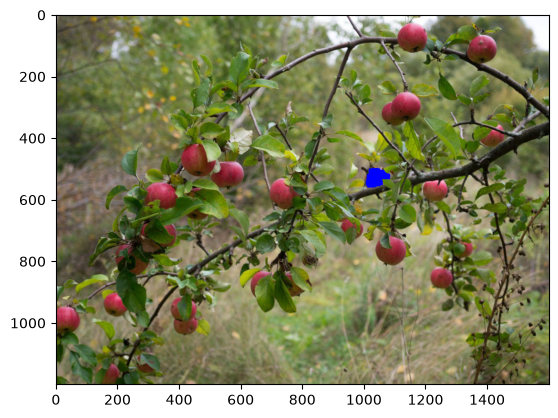

In [93]:
#Task 3
filled = image.copy()
cv2.drawContours(filled, [cnts[20]], -1, (0, 0, 255), -1)
plt.imshow(filled)

Experiment 1 applies blurring first so the background is considered as noise. The background gets defocused so we mostly keep the leaved in the tree that is closer to the camera. Then we apply a green mask filtering to keep the greenish colors of the leaves.  

(np.float64(-0.5), np.float64(1599.5), np.float64(1199.5), np.float64(-0.5))

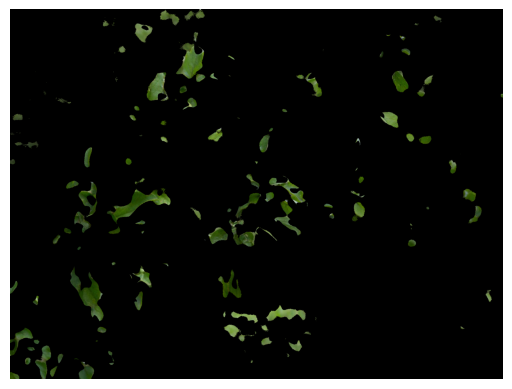

In [94]:
#Task 4

# Experiment 1

blurred = cv2.GaussianBlur(image, (45, 45), 0)
plt.imshow(blurred)
hsv = cv2.cvtColor(blurred, cv2.COLOR_RGB2HSV)

# define green color range
lower_green = np.array([41, 100, 60])
upper_green = np.array([90, 255, 255])

green_mask = cv2.inRange(hsv, lower_green, upper_green)
green_image = cv2.bitwise_and(image, image, mask=green_mask)

plt.imshow(green_image)
plt.axis("off")


Experiment 2 does not apply blurring like before. It only applies the green mask filtering. In that case, the shape of the leaves is better depicted but there is more backround noise that hasn't been reduced.

(np.float64(-0.5), np.float64(1599.5), np.float64(1199.5), np.float64(-0.5))

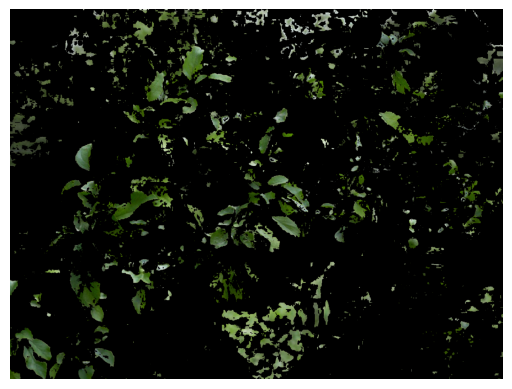

In [95]:
# Experiment 2

hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

# define green color range
lower_green = np.array([41, 10, 60])
upper_green = np.array([90, 255, 255])

green_mask = cv2.inRange(hsv, lower_green, upper_green)
green_image = cv2.bitwise_and(image, image, mask=green_mask)

plt.imshow(green_image)
plt.axis("off")

## PART 2

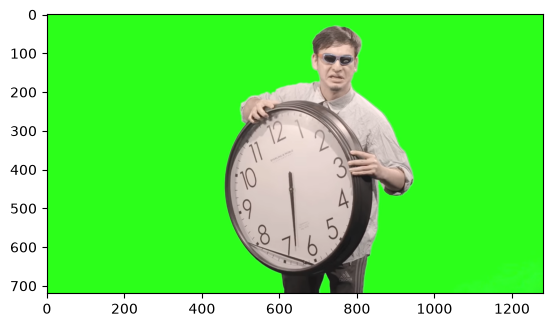

In [96]:
# Task 1
path = "ittsp.png"
bgr_img = cv2.imread(path)
b,g,r = cv2.split(bgr_img)
image = cv2.merge([r,g,b])
plt.imshow(image)

We apply a green mask filtering to identify the green area of the image. The detected green area is then replaced with appletree.jpg as the new background. After that, erosion and dilation are applied to experiment if the edges are modified in that case.

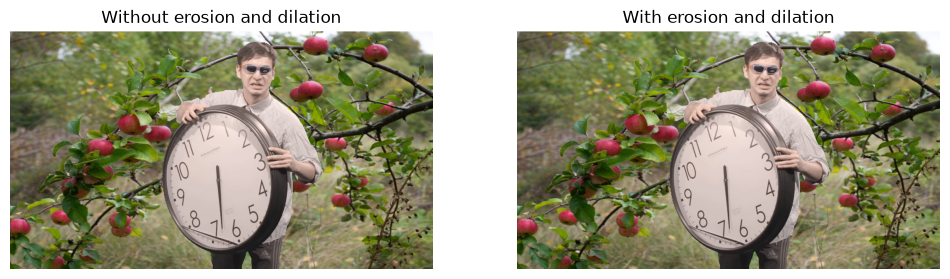

In [100]:
# RGB image -> HSV
hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV) 

lower_green = np.array([25, 40, 60])
upper_green = np.array([90, 255, 255])
green_mask = cv2.inRange(hsv, lower_green, upper_green)

# appletree.jpg will be used as a replacement 
background = cv2.imread("appletree.jpg")
background = cv2.cvtColor(background, cv2.COLOR_BGR2RGB)
background = cv2.resize(background, (image.shape[1], image.shape[0]))

final_image_original = np.where(green_mask[:, :, None] == 255, background, image)
mask = green_mask.copy()
kernel = np.ones((3, 3), np.uint8)
mask = cv2.erode(mask, kernel, iterations=3)
mask = cv2.dilate(mask, kernel, iterations=3)

final_image_processed = np.where(mask[:, :, None] == 255, background, image)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(final_image_original)
plt.title("Without erosion and dilation")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(final_image_processed)
plt.title("With erosion and dilation")
plt.axis("off")

plt.show()

After erosion and dilation, no change was observed in the edges of the central figure. That is because the combination of erosion and dilation is used to erase small objects or holes, and not for sharpening big objects like this one.